# CS224N — 0-Shot Evaluation: Comprehensive Metrics Analysis

Auto-discovers all `*_final_metrics.json` files under `../0_shot/` and produces:

1. Unified metrics table (3 models × 6 benchmarks — full grid)
2. Accuracy comparison bar charts
3. Throughput (tokens/sec) comparison
4. Efficiency: accuracy vs. inference time
5. RAFT per-task breakdown (all 3 models × 10 subtasks)
6. IFBench strict/loose instruction-following analysis
7. Radar chart (model capability profile)
8. Pareto: model size & throughput vs. accuracy
9. Summary dashboard (5-panel)
10. Key findings

In [28]:
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '0_shot'))
OUT_DIR  = os.path.abspath(os.getcwd())
print(f'Metrics root: {BASE_DIR}')

Metrics root: /Users/danielgrossman/224nProject/CS224N-TheEfficiencyThreshold/src/0_shot


## 1. Auto-Discover & Load All Metrics

In [30]:
# ── Constants ──────────────────────────────────────────────────────────────
MODEL_LABELS = {
    'meta-llama/Meta-Llama-3-8B-Instruct': 'Llama-3 8B',
    'Qwen/Qwen3-4B':                        'Qwen3 4B',
    'Qwen/Qwen3-4B-Instruct-2507':          'Qwen3 4B',
    'Qwen/Qwen3-8B':                        'Qwen3 8B',
}
MODEL_SIZES  = {'Llama-3 8B': 8, 'Qwen3 4B': 4, 'Qwen3 8B': 8}
MODEL_COLORS = {'Llama-3 8B': '#4C72B0', 'Qwen3 4B': '#DD8452', 'Qwen3 8B': '#55A868'}
MODELS_ORDERED = ['Llama-3 8B', 'Qwen3 4B', 'Qwen3 8B']

TASK_LABELS = {
    'financial_phrase_bank': 'Financial PhraseBank',
    'gsm8k':                'GSM8K (Math)',
    'superglue_boolq':      'SuperGLUE BoolQ',
    'superglue_rte':        'SuperGLUE RTE',
    'raft':                 'RAFT (mean)',
    'ifbench':              'IFBench',
}
ALL_TASKS_ORDERED = list(TASK_LABELS.values())

# ── Discover JSON files ────────────────────────────────────────────────────
json_files = sorted(glob.glob(os.path.join(BASE_DIR, '**', '*final_metrics*.json'), recursive=True))
# Skip files in (OLD) directories
json_files = [f for f in json_files if '(OLD)' not in f]
print(f'Found {len(json_files)} metrics files (excluding OLD):')
for f in json_files:
    print(f'  {os.path.relpath(f, BASE_DIR)}')

Found 18 metrics files (excluding OLD):
  financial_phrase_bank/llama_3_8b/llama_3_8b_FinPB_0shot_final_metrics.json
  financial_phrase_bank/qwen_3_4b/qwen_3_4b_FinPB_0shot_final_metrics.json
  financial_phrase_bank/qwen_3_8b/qwen_3_8b_FinPB_0shot_final_metrics.json
  gsm8k/llama_3_8b/llama_3_8b_gsm8k_0shot_final_metrics.json
  gsm8k/qwen_3_4b/qwen_3_4b_gsm8k_0shot_final_metrics.json
  gsm8k/qwen_3_8b/qwen_3_8b_gsm8k_0shot_final_metrics.json
  ifbench/llama_3_8b/llama_3_8b_ifbench_0shot_final_metrics.json
  ifbench/qwen_3_4b/qwen_3_4b_ifbench_0shot_final_metrics.json
  ifbench/qwen_3_8b/qwen_3_8b_ifbench_0shot_final_metrics.json
  raft/llama_3_8b/llama_3_8b_raft_0shot_final_metrics.json
  raft/qwen_3_4b/qwen_3_4b_raft_0shot_final_metrics.json
  raft/qwen_3_8b/qwen_3_8b_raft_0shot_final_metrics.json
  superglue/boolq/llama_3_8b/llama_3_3b_boolq_0_shot_final_metrics.json
  superglue/boolq/qwen_3_4b/qwen_3_4b_boolq_0shot_final_metrics.json
  superglue/boolq/qwen_3_8b/qwen_3_8b_boolq_0shot

In [45]:
def classify_task(filepath):
    """Determine the task key from the file path."""
    rel = os.path.relpath(filepath, BASE_DIR)
    parts = rel.replace(os.sep, '/').lower()
    if 'ifbench' in parts:   return 'ifbench'
    if 'raft' in parts:      return 'raft'
    if 'gsm8k' in parts or 'gs8mk' in parts: return 'gsm8k'
    if 'boolq' in parts:     return 'superglue_boolq'
    if 'rte' in parts:       return 'superglue_rte'
    if 'financial' in parts or 'finpb' in parts: return 'financial_phrase_bank'
    return 'unknown'

rows = []
raft_per_task = {}   # model_label -> list of per-task dicts
ifbench_details = {} # model_label -> dict with strict/loose

for filepath in json_files:
    with open(filepath) as f:
        m = json.load(f)

    task_key = classify_task(filepath)
    model_raw = m.get('model', '')
    model_label = MODEL_LABELS.get(model_raw, model_raw)

    if task_key == 'raft':
        acc = m.get('mean_accuracy')
        per_task_list = m.get('per_task', [])
        raft_per_task[model_label] = per_task_list
        total_tokens = sum(pt.get('total_new_tokens', 0) for pt in per_task_list)
        total_time_min = sum(pt.get('gen_time_min', 0) for pt in per_task_list)
        total_test = sum(pt.get('n_test', 0) for pt in per_task_list)
        tgm = total_time_min if total_time_min > 0 else None
        tps = total_tokens / (total_time_min * 60) if total_time_min > 0 else None
        esz = total_test if total_test > 0 else None
    elif task_key == 'ifbench':
        acc = m.get('loose_prompt_accuracy')
        tps = m.get('gen_tokens_per_sec')
        tgm = m.get('total_gen_time_min')
        esz = m.get('eval_size')
        ifbench_details[model_label] = {
            'strict_prompt':  m.get('strict_prompt_accuracy'),
            'strict_instr':   m.get('strict_instruction_accuracy'),
            'loose_prompt':   m.get('loose_prompt_accuracy'),
            'loose_instr':    m.get('loose_instruction_accuracy'),
            'tokens_per_sec': tps,
            'gen_time_min':   tgm,
        }
    else:
        acc = m.get('accuracy')
        tps = m.get('gen_tokens_per_sec')
        tgm = m.get('total_gen_time_min')
        esz = m.get('eval_size')

    rows.append({
        'task':              task_key,
        'task_label':        TASK_LABELS.get(task_key, task_key),
        'model_raw':         model_raw,
        'model':             model_label,
        'accuracy':          acc,
        'gen_tokens_per_sec': tps,
        'total_gen_time_min': tgm,
        'eval_size':         esz,
    })

df = pd.DataFrame(rows)
print(f'\nLoaded {len(df)} entries: {df["task"].nunique()} tasks × {df["model"].nunique()} models')
print(f'\nCoverage matrix (accuracy):')
coverage = df.pivot_table(index='task_label', columns='model', values='accuracy', aggfunc='first')
coverage = coverage.reindex(index=ALL_TASKS_ORDERED, columns=MODELS_ORDERED)
print((coverage * 100).round(2).fillna('MISSING').to_string())


Loaded 18 entries: 6 tasks × 3 models

Coverage matrix (accuracy):
model                 Llama-3 8B  Qwen3 4B  Qwen3 8B
task_label                                          
Financial PhraseBank       90.60     90.00     96.30
GSM8K (Math)               77.26     85.29     87.64
SuperGLUE BoolQ            84.56     85.44     86.79
SuperGLUE RTE              78.34     86.64     85.92
RAFT (mean)                36.80     39.60     40.80
IFBench                    28.67     33.33     30.00


## 2. Summary Tables

In [32]:
pivot_acc = df.pivot_table(
    index='task_label', columns='model', values='accuracy', aggfunc='first'
).reindex(index=ALL_TASKS_ORDERED, columns=MODELS_ORDERED)

pivot_acc.loc['** MEAN **'] = pivot_acc.mean()

display_acc = (pivot_acc * 100).round(2).astype(str) + '%'
display_acc = display_acc.replace('nan%', '---')
print('=== Accuracy by Model x Task (%) ===')
print(display_acc.to_string())

print('\n=== Throughput (tok/s) by Model x Task ===')
pivot_tps = df.pivot_table(
    index='task_label', columns='model', values='gen_tokens_per_sec', aggfunc='first'
).reindex(index=ALL_TASKS_ORDERED, columns=MODELS_ORDERED)
print(pivot_tps.round(1).fillna('---').to_string())

=== Accuracy by Model x Task (%) ===
model                Llama-3 8B Qwen3 4B Qwen3 8B
task_label                                       
Financial PhraseBank      90.6%    90.0%    96.3%
GSM8K (Math)             77.26%   85.29%   87.64%
SuperGLUE BoolQ          84.56%   85.44%   86.79%
SuperGLUE RTE            78.34%   86.64%   85.92%
RAFT (mean)               36.8%    39.6%    40.8%
IFBench                  28.67%   33.33%    30.0%
** MEAN **               66.04%   70.05%   71.24%

=== Throughput (tok/s) by Model x Task ===
model                Llama-3 8B Qwen3 4B Qwen3 8B
task_label                                       
Financial PhraseBank       12.3     24.9    126.8
GSM8K (Math)             1056.2   1805.8    876.3
SuperGLUE BoolQ            44.2    105.2     44.2
SuperGLUE RTE             172.1    309.8    156.5
RAFT (mean)                 ---      ---      ---
IFBench                   523.7   1081.2    413.9


## 3. Accuracy Comparison — All 6 Benchmarks

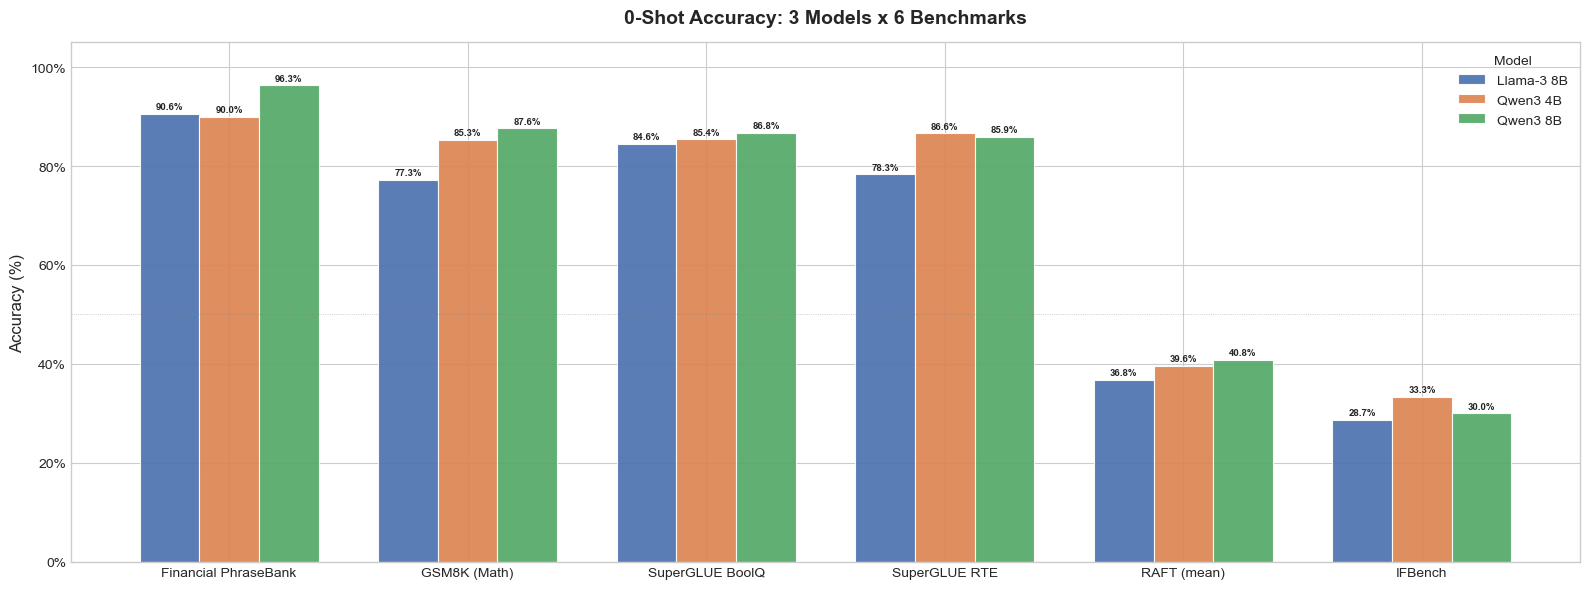

Saved: accuracy_comparison.png


In [43]:
x = np.arange(len(ALL_TASKS_ORDERED))
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(16, 6))

for i, model in enumerate(MODELS_ORDERED):
    vals = []
    for tl in ALL_TASKS_ORDERED:
        row = df[(df['task_label'] == tl) & (df['model'] == model)]
        vals.append(row['accuracy'].values[0] * 100 if len(row) else np.nan)
    bars = ax.bar(
        x + offsets[i], vals, width,
        label=model, color=MODEL_COLORS[model],
        edgecolor='white', linewidth=0.8, alpha=0.92
    )
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=7, fontweight='bold'
            )

ax.set_xticks(x)
ax.set_xticklabels(ALL_TASKS_ORDERED, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('0-Shot Accuracy: 3 Models x 6 Benchmarks', fontsize=14, fontweight='bold', pad=14)
ax.set_ylim(0, 105)
ax.legend(title='Model', fontsize=10, title_fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.axhline(y=50, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'accuracy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: accuracy_comparison.png')

## 4. Throughput (Tokens/sec) Comparison

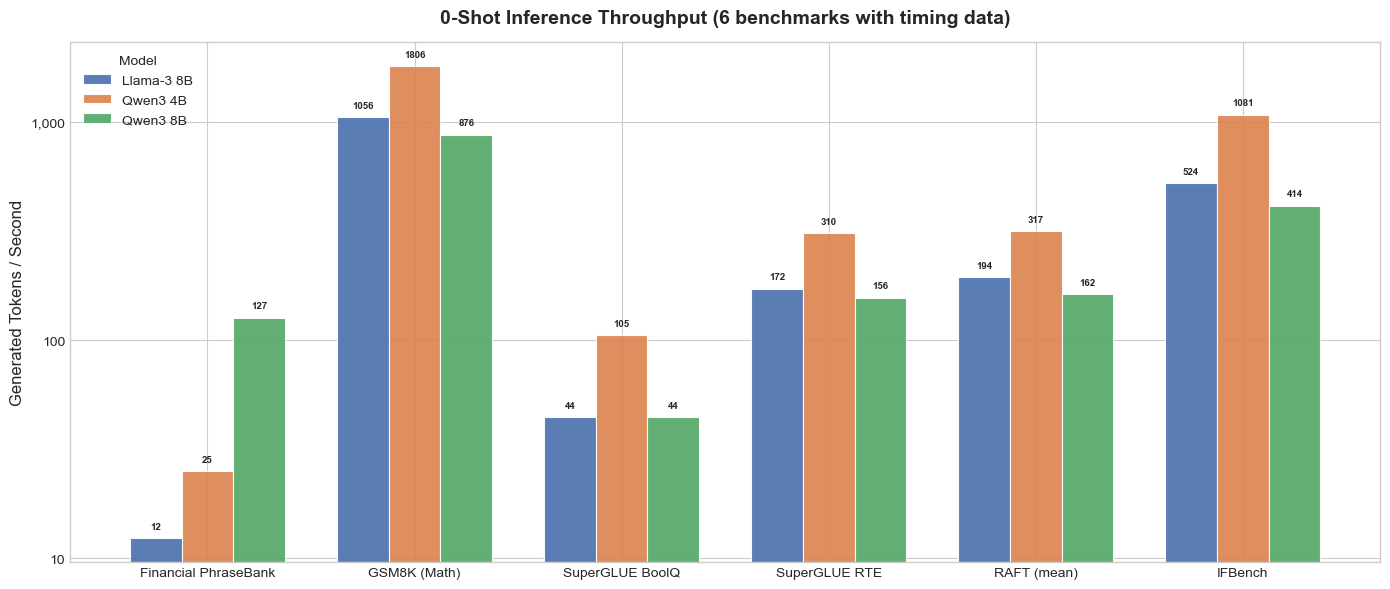

Saved: throughput_comparison.png


In [47]:
TASKS_WITH_TPS = ALL_TASKS_ORDERED
df_tps = df[df['task_label'].isin(TASKS_WITH_TPS)].dropna(subset=['gen_tokens_per_sec']).copy()

x2 = np.arange(len(TASKS_WITH_TPS))

fig, ax = plt.subplots(figsize=(14, 6))

for i, model in enumerate(MODELS_ORDERED):
    vals = []
    for tl in TASKS_WITH_TPS:
        row = df_tps[(df_tps['task_label'] == tl) & (df_tps['model'] == model)]
        vals.append(row['gen_tokens_per_sec'].values[0] if len(row) else np.nan)
    bars = ax.bar(
        x2 + offsets[i], vals, width,
        label=model, color=MODEL_COLORS[model],
        edgecolor='white', linewidth=0.8, alpha=0.92
    )
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            label_val = f'{v:.0f}' if v >= 10 else f'{v:.1f}'
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.08,
                    label_val, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x2)
ax.set_xticklabels(TASKS_WITH_TPS, fontsize=10)
ax.set_ylabel('Generated Tokens / Second', fontsize=12)
ax.set_title('0-Shot Inference Throughput (6 benchmarks with timing data)', fontsize=14, fontweight='bold', pad=14)
ax.legend(title='Model', fontsize=10, title_fontsize=10)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:,.0f}'))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'throughput_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: throughput_comparison.png')

## 5. Efficiency: Accuracy vs. Inference Time

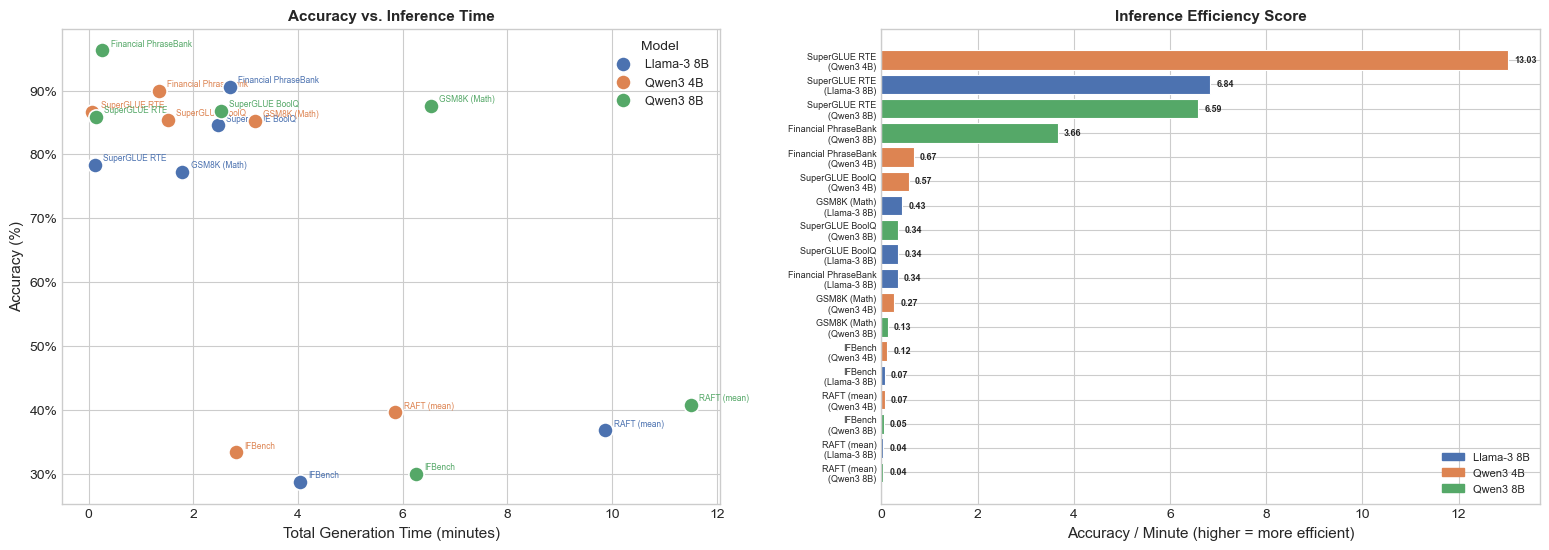

Saved: efficiency_analysis.png


In [48]:
df_eff = df.dropna(subset=['total_gen_time_min']).copy()
df_eff['acc_per_min'] = df_eff['accuracy'] / df_eff['total_gen_time_min']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: scatter accuracy vs. gen time ───────────────────────────────────
ax = axes[0]
for model in MODELS_ORDERED:
    sub = df_eff[df_eff['model'] == model]
    ax.scatter(
        sub['total_gen_time_min'], sub['accuracy'] * 100,
        label=model, color=MODEL_COLORS[model],
        s=120, zorder=5, edgecolors='white', linewidths=1.2
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['task_label'],
            (row['total_gen_time_min'], row['accuracy'] * 100),
            xytext=(6, 3), textcoords='offset points',
            fontsize=6, color=MODEL_COLORS[model]
        )

ax.set_xlabel('Total Generation Time (minutes)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy vs. Inference Time', fontsize=11, fontweight='bold')
ax.legend(title='Model', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# ── Right: accuracy-per-minute bar (top entries) ──────────────────────────
ax2 = axes[1]
eff_sorted = df_eff.sort_values('acc_per_min', ascending=True)
colors_bar = [MODEL_COLORS[m] for m in eff_sorted['model']]
labels_bar = eff_sorted['task_label'] + '\n(' + eff_sorted['model'] + ')'

bars = ax2.barh(labels_bar, eff_sorted['acc_per_min'], color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, eff_sorted['acc_per_min']):
    ax2.text(v + max(eff_sorted['acc_per_min']) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{v:.2f}', va='center', ha='left', fontsize=6.5, fontweight='bold')

ax2.set_xlabel('Accuracy / Minute (higher = more efficient)', fontsize=11)
ax2.set_title('Inference Efficiency Score', fontsize=11, fontweight='bold')
legend_patches = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODELS_ORDERED]
ax2.legend(handles=legend_patches, fontsize=8)
ax2.tick_params(axis='y', labelsize=6.5)

plt.tight_layout(pad=2.5)
plt.savefig(os.path.join(OUT_DIR, 'efficiency_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: efficiency_analysis.png')

## 6. RAFT Per-Task Breakdown — All 3 Models

In [36]:
RAFT_NICE_NAMES = {
    'ade_corpus_v2': 'ADE Corpus v2',
    'banking_77': 'Banking-77',
    'neurips_impact_statement_risks': 'NeurIPS Impact',
    'one_stop_english': 'One Stop English',
    'overruling': 'Overruling',
    'semiconductor_org_types': 'Semiconductor Orgs',
    'tai_safety_research': 'TAI Safety',
    'terms_of_service': 'Terms of Service',
    'tweet_eval_hate': 'Tweet Eval Hate',
    'twitter_complaints': 'Twitter Complaints',
}

raft_rows = []
for model_label in MODELS_ORDERED:
    for pt in raft_per_task.get(model_label, []):
        raft_rows.append({
            'model': model_label,
            'task':  RAFT_NICE_NAMES.get(pt['task'], pt['task']),
            'accuracy': pt['accuracy'],
            'n_test': pt['n_test'],
            'throughput': pt.get('throughput_tok_per_sec'),
        })

raft_df = pd.DataFrame(raft_rows)
raft_pivot = raft_df.pivot_table(index='task', columns='model', values='accuracy', aggfunc='first')
raft_pivot = raft_pivot.reindex(columns=MODELS_ORDERED)

print('RAFT Per-Task Accuracy (%):')
print((raft_pivot * 100).round(1).to_string())
print(f'\nMeans: {dict((raft_pivot * 100).mean().round(2))}')

RAFT Per-Task Accuracy (%):
model               Llama-3 8B  Qwen3 4B  Qwen3 8B
task                                              
ADE Corpus v2             18.0      22.0      14.0
Banking-77                14.0      22.0      24.0
NeurIPS Impact            80.0      86.0      90.0
One Stop English          38.0      40.0      40.0
Overruling                90.0      98.0      96.0
Semiconductor Orgs         6.0       4.0       2.0
TAI Safety                32.0      18.0      28.0
Terms of Service          56.0      68.0      76.0
Tweet Eval Hate           24.0      30.0      26.0
Twitter Complaints        10.0       8.0      12.0

Means: {'Llama-3 8B': np.float64(36.8), 'Qwen3 4B': np.float64(39.6), 'Qwen3 8B': np.float64(40.8)}


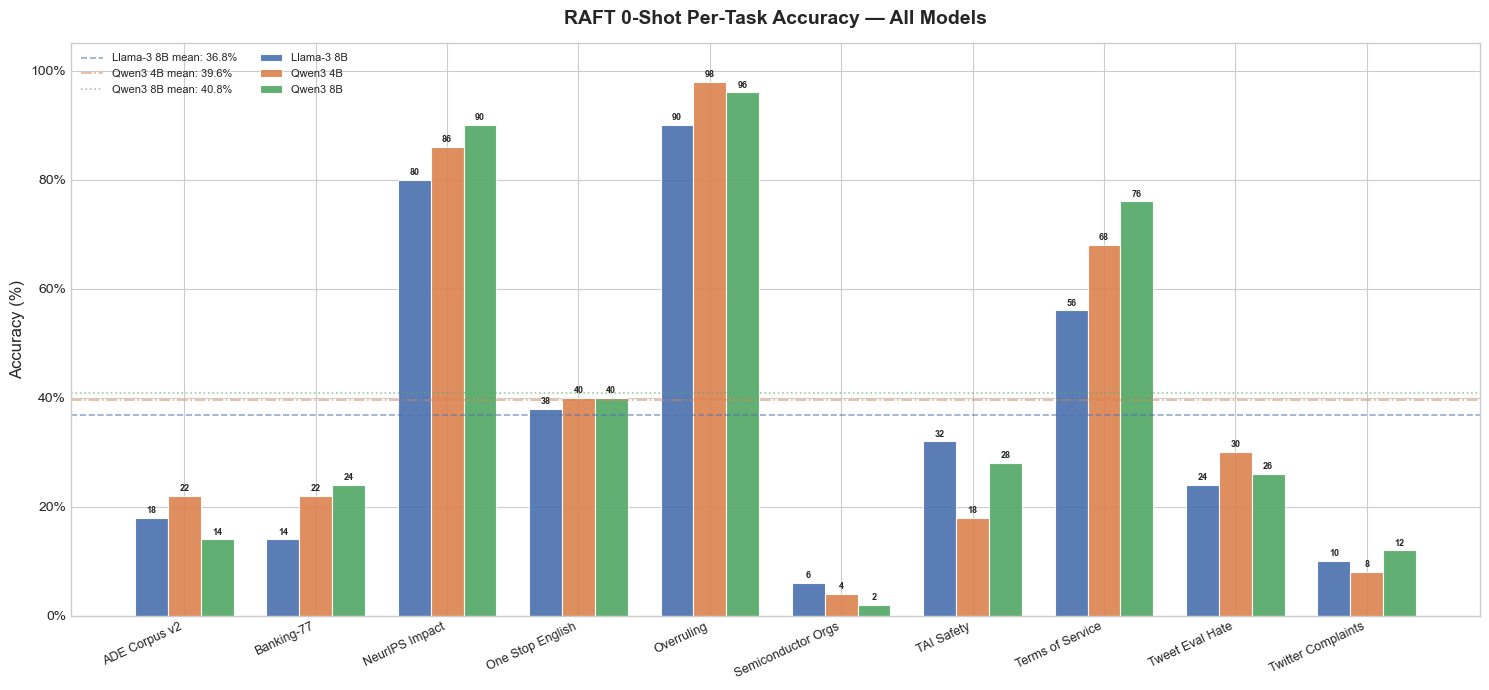

Saved: raft_breakdown.png


In [37]:
RAFT_TASK_NAMES = list(raft_pivot.index)

fig, ax = plt.subplots(figsize=(15, 7))

x_r = np.arange(len(RAFT_TASK_NAMES))
w = 0.25

for i, model in enumerate(MODELS_ORDERED):
    vals = (raft_pivot[model].values * 100)
    bars = ax.bar(
        x_r + (i - 1) * w, vals, w,
        label=model, color=MODEL_COLORS[model],
        edgecolor='white', linewidth=0.8, alpha=0.92
    )
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=6.5, fontweight='bold')

for i, model in enumerate(MODELS_ORDERED):
    mean_val = raft_pivot[model].mean() * 100
    ls = ['--', '-.', ':'][i]
    ax.axhline(mean_val, color=MODEL_COLORS[model], linestyle=ls,
               linewidth=1.2, alpha=0.6, label=f'{model} mean: {mean_val:.1f}%')

ax.set_xticks(x_r)
ax.set_xticklabels(RAFT_TASK_NAMES, fontsize=9, rotation=25, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('RAFT 0-Shot Per-Task Accuracy — All Models', fontsize=14, fontweight='bold', pad=14)
ax.set_ylim(0, 105)
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'raft_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: raft_breakdown.png')

In [ ]:
# ── Load all train_results.json files ─────────────────────────────────────
RAFT_DIR = os.path.join(BASE_DIR, 'raft')
MODEL_DIRS = {
    'Llama-3 8B': 'llama_3_8b',
    'Qwen3 4B':   'qwen_3_4b',
    'Qwen3 8B':   'qwen_3_8b',
}
RAFT_TASKS_ORDERED = [
    'ade_corpus_v2', 'banking_77', 'neurips_impact_statement_risks',
    'one_stop_english', 'overruling', 'semiconductor_org_types',
    'tai_safety_research', 'terms_of_service', 'tweet_eval_hate',
    'twitter_complaints',
]

# train_results[model][task] = list of {ground_truth, prediction, is_correct, is_unknown}
train_results = {}
for model_label, model_dir in MODEL_DIRS.items():
    train_results[model_label] = {}
    for task in RAFT_TASKS_ORDERED:
        path = os.path.join(RAFT_DIR, model_dir, task, 'train_results.json')
        if os.path.exists(path):
            with open(path) as f:
                train_results[model_label][task] = json.load(f)

# ── Compute per-task accuracy from train split (should match final_metrics) ─
print('Train-split accuracy check (50 examples each):')
print(f'{"Task":<35}', '  '.join(f'{m:>12}' for m in MODELS_ORDERED))
for task in RAFT_TASKS_ORDERED:
    row_accs = []
    for model in MODELS_ORDERED:
        preds = train_results.get(model, {}).get(task, [])
        if preds:
            acc = sum(p['is_correct'] for p in preds) / len(preds)
            row_accs.append(f'{acc*100:>11.1f}%')
        else:
            row_accs.append('     MISSING')
    print(f'{RAFT_NICE_NAMES.get(task, task):<35}', '  '.join(row_accs))

# ── Compute prediction distributions ───────────────────────────────────────
def pred_distribution(preds):
    """Return {label: count} for predictions, ground truths, and per-label accuracy."""
    from collections import Counter
    pred_counts  = Counter(p['prediction']    for p in preds if not p['is_unknown'])
    gt_counts    = Counter(p['ground_truth']  for p in preds)
    labels = sorted(set(gt_counts) | set(pred_counts))
    per_label_acc = {}
    for lbl in labels:
        subset = [p for p in preds if p['ground_truth'] == lbl]
        per_label_acc[lbl] = sum(p['is_correct'] for p in subset) / len(subset) if subset else 0.0
    return pred_counts, gt_counts, per_label_acc, labels

# ── Figure 1: Prediction bias heatmap ──────────────────────────────────────
# For binary tasks, show fraction predicted as "class 2" (positive class) vs ground truth fraction.
binary_tasks = [t for t in RAFT_TASKS_ORDERED if t not in ('banking_77', 'one_stop_english', 'semiconductor_org_types')]

fig, axes = plt.subplots(1, len(MODELS_ORDERED), figsize=(16, 5), sharey=True)
fig.suptitle('RAFT Train-Split: Predicted vs. True Positive-Class Fraction\n(binary tasks only — "class 2" = positive label)',
             fontsize=13, fontweight='bold', y=1.02)

for ax_idx, model in enumerate(MODELS_ORDERED):
    ax = axes[ax_idx]
    pred_fracs, gt_fracs = [], []
    task_names = []
    for task in binary_tasks:
        preds = train_results.get(model, {}).get(task, [])
        if not preds:
            continue
        pred_counts, gt_counts, _, _ = pred_distribution(preds)
        n = len(preds)
        pred_fracs.append(pred_counts.get(2, 0) / n)
        gt_fracs.append(gt_counts.get(2, 0) / n)
        task_names.append(RAFT_NICE_NAMES.get(task, task))

    y = np.arange(len(task_names))
    bars_gt   = ax.barh(y - 0.18, [f * 100 for f in gt_fracs],   0.35,
                        label='Ground truth', color='#aec6e8', edgecolor='white')
    bars_pred = ax.barh(y + 0.18, [f * 100 for f in pred_fracs], 0.35,
                        label='Predicted',    color=MODEL_COLORS[model], edgecolor='white', alpha=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(task_names, fontsize=8)
    ax.set_xlabel('% labelled as positive class', fontsize=9)
    ax.set_title(model, fontweight='bold', fontsize=11)
    ax.set_xlim(0, 105)
    ax.axvline(50, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    if ax_idx == 0:
        ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'raft_prediction_bias.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: raft_prediction_bias.png')

# ── Figure 2: Per-label accuracy for every task × model ────────────────────
n_tasks = len(RAFT_TASKS_ORDERED)
fig, axes = plt.subplots(n_tasks, len(MODELS_ORDERED),
                         figsize=(14, n_tasks * 1.4), sharex=False)
fig.suptitle('RAFT Train-Split: Per-Class Accuracy (n=50)', fontsize=13, fontweight='bold', y=1.005)

for t_idx, task in enumerate(RAFT_TASKS_ORDERED):
    for m_idx, model in enumerate(MODELS_ORDERED):
        ax = axes[t_idx][m_idx]
        preds = train_results.get(model, {}).get(task, [])
        if not preds:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            continue
        pred_counts, gt_counts, per_label_acc, labels = pred_distribution(preds)
        label_strs = [str(l) for l in labels]
        accs = [per_label_acc[l] * 100 for l in labels]
        gt_ns = [gt_counts.get(l, 0) for l in labels]
        bar_colors = [MODEL_COLORS[model] if a > 0 else '#dddddd' for a in accs]
        ax.bar(label_strs, accs, color=bar_colors, edgecolor='white', linewidth=0.5)
        ax.set_ylim(0, 110)
        ax.tick_params(axis='both', labelsize=6)
        for i, (a, n) in enumerate(zip(accs, gt_ns)):
            ax.text(i, a + 2, f'{a:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=5)
        if t_idx == 0:
            ax.set_title(model, fontsize=9, fontweight='bold')
        if m_idx == 0:
            ax.set_ylabel(RAFT_NICE_NAMES.get(task, task), fontsize=6.5, rotation=0,
                          labelpad=70, va='center')
        ax.set_xlabel('Label', fontsize=6)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'raft_per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: raft_per_class_accuracy.png')

# ── Figure 3: Model agreement on individual examples ──────────────────────
print('\nModel agreement analysis (binary tasks, 50 examples each):')
print(f'{"Task":<35} {"All 3 agree":>12} {"All correct":>12} {"All wrong":>12} {"Llama≠Qwen":>12}')
for task in RAFT_TASKS_ORDERED:
    preds_by_model = {m: train_results.get(m, {}).get(task, []) for m in MODELS_ORDERED}
    if not all(len(v) == 50 for v in preds_by_model.values()):
        continue
    n = 50
    all_agree = sum(
        len({preds_by_model[m][i]['prediction'] for m in MODELS_ORDERED}) == 1
        for i in range(n)
    )
    all_correct = sum(
        all(preds_by_model[m][i]['is_correct'] for m in MODELS_ORDERED)
        for i in range(n)
    )
    all_wrong = sum(
        not any(preds_by_model[m][i]['is_correct'] for m in MODELS_ORDERED)
        for i in range(n)
    )
    llama_diff = sum(
        preds_by_model['Llama-3 8B'][i]['prediction'] != preds_by_model['Qwen3 8B'][i]['prediction']
        for i in range(n)
    )
    print(f'{RAFT_NICE_NAMES.get(task, task):<35} {all_agree:>11} {all_correct:>12} {all_wrong:>12} {llama_diff:>12}')

: 

## 6b. RAFT Train-Split: Prediction Distribution & Label Bias

Loads the per-example `train_results.json` files (50 predictions per subtask) to visualise **how each model distributes its predictions** across the available labels — revealing whether low accuracy is caused by systematic label bias (e.g. always predicting class 1) rather than genuine task difficulty.

## 7. IFBench Analysis

IFBench Results (300 prompts, 344 constraints, 58 types):
     Model  Strict Prompt  Strict Instr  Loose Prompt  Loose Instr  Tokens/sec  Gen Time (min)
Llama-3 8B         0.2133        0.2326        0.2867       0.3198      523.74           4.029
  Qwen3 4B         0.3033        0.3314        0.3333       0.3663     1081.19           2.807
  Qwen3 8B         0.2567        0.2878        0.3000       0.3401      413.91           6.255


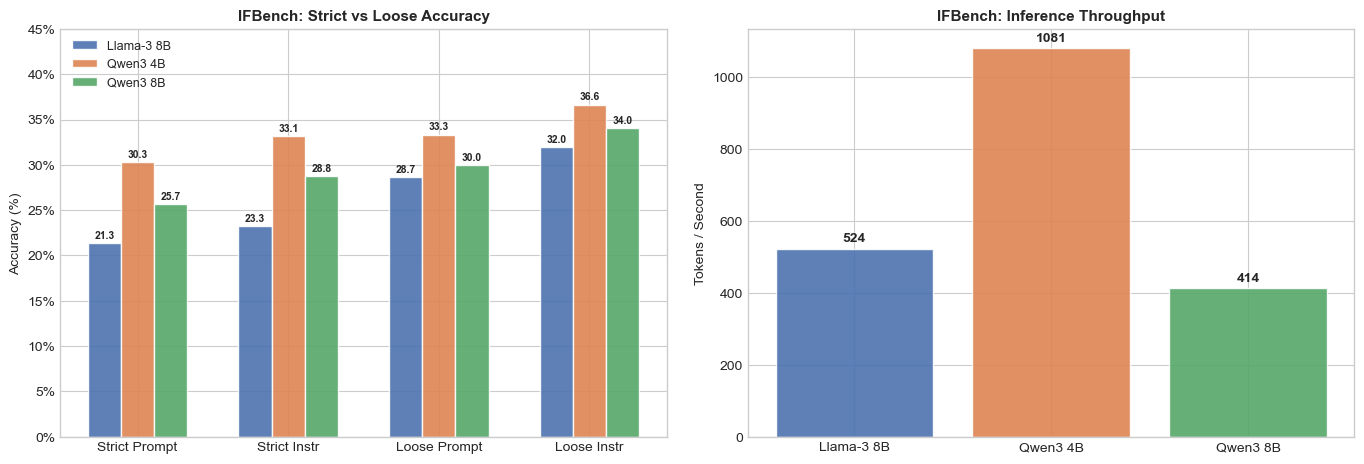

Saved: ifbench_analysis.png


In [38]:
ifbench_rows = []
for model in MODELS_ORDERED:
    d = ifbench_details.get(model, {})
    ifbench_rows.append({
        'Model': model,
        'Strict Prompt': d.get('strict_prompt'),
        'Strict Instr':  d.get('strict_instr'),
        'Loose Prompt':  d.get('loose_prompt'),
        'Loose Instr':   d.get('loose_instr'),
        'Tokens/sec':    d.get('tokens_per_sec'),
        'Gen Time (min)': d.get('gen_time_min'),
    })
ifbench_df = pd.DataFrame(ifbench_rows)

print('IFBench Results (300 prompts, 344 constraints, 58 types):')
print(ifbench_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: strict vs loose ─────────────────────────────────────────────────
ax = axes[0]
metrics_to_plot = ['Strict Prompt', 'Strict Instr', 'Loose Prompt', 'Loose Instr']
x_if = np.arange(len(metrics_to_plot))
w_if = 0.22

for i, model in enumerate(MODELS_ORDERED):
    vals = [ifbench_df.loc[ifbench_df['Model'] == model, m].values[0] * 100 for m in metrics_to_plot]
    bars = ax.bar(x_if + (i - 1) * w_if, vals, w_if,
                  label=model, color=MODEL_COLORS[model], edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x_if)
ax.set_xticklabels(metrics_to_plot, fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('IFBench: Strict vs Loose Accuracy', fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_ylim(0, 45)

# ── Right: throughput ─────────────────────────────────────────────────────
ax2 = axes[1]
tps_vals = [ifbench_details.get(m, {}).get('tokens_per_sec', 0) for m in MODELS_ORDERED]
bars = ax2.bar(MODELS_ORDERED, tps_vals,
               color=[MODEL_COLORS[m] for m in MODELS_ORDERED],
               edgecolor='white', alpha=0.9)
for bar, v in zip(bars, tps_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f'{v:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Tokens / Second')
ax2.set_title('IFBench: Inference Throughput', fontweight='bold', fontsize=11)

plt.tight_layout(pad=2)
plt.savefig(os.path.join(OUT_DIR, 'ifbench_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ifbench_analysis.png')

## 8. Radar Chart — Model Capability Profile

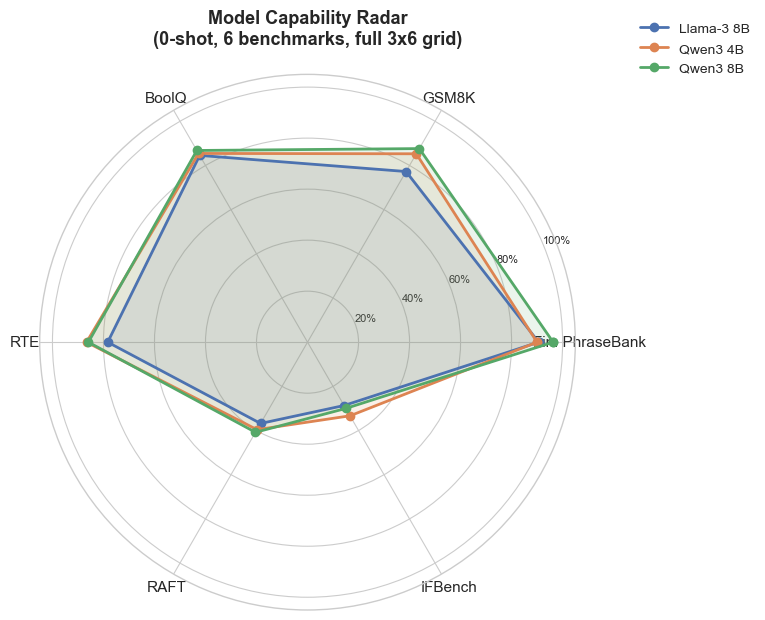

Saved: radar_chart.png


In [39]:
radar_labels = ['Fin. PhraseBank', 'GSM8K', 'BoolQ', 'RTE', 'RAFT', 'IFBench']
radar_tasks  = ALL_TASKS_ORDERED  # same order
N_radar = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N_radar, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODELS_ORDERED:
    vals = []
    for tl in radar_tasks:
        row = df[(df['task_label'] == tl) & (df['model'] == model)]
        vals.append(row['accuracy'].values[0] if len(row) else 0)
    vals_closed = vals + vals[:1]
    ax.plot(angles, vals_closed, 'o-', linewidth=2, label=model, color=MODEL_COLORS[model])
    ax.fill(angles, vals_closed, alpha=0.12, color=MODEL_COLORS[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax.set_title('Model Capability Radar\n(0-shot, 6 benchmarks, full 3x6 grid)', fontsize=13, fontweight='bold', pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'radar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: radar_chart.png')

## 9. Pareto: Model Size & Throughput vs. Accuracy

Mean accuracy per model (all 6 tasks):
  Llama-3 8B: 66.04%
  Qwen3 4B: 70.05%
  Qwen3 8B: 71.24%

Mean throughput per model (tasks with timing):
  Llama-3 8B: 361.7 tok/s
  Qwen3 4B: 665.4 tok/s
  Qwen3 8B: 323.5 tok/s


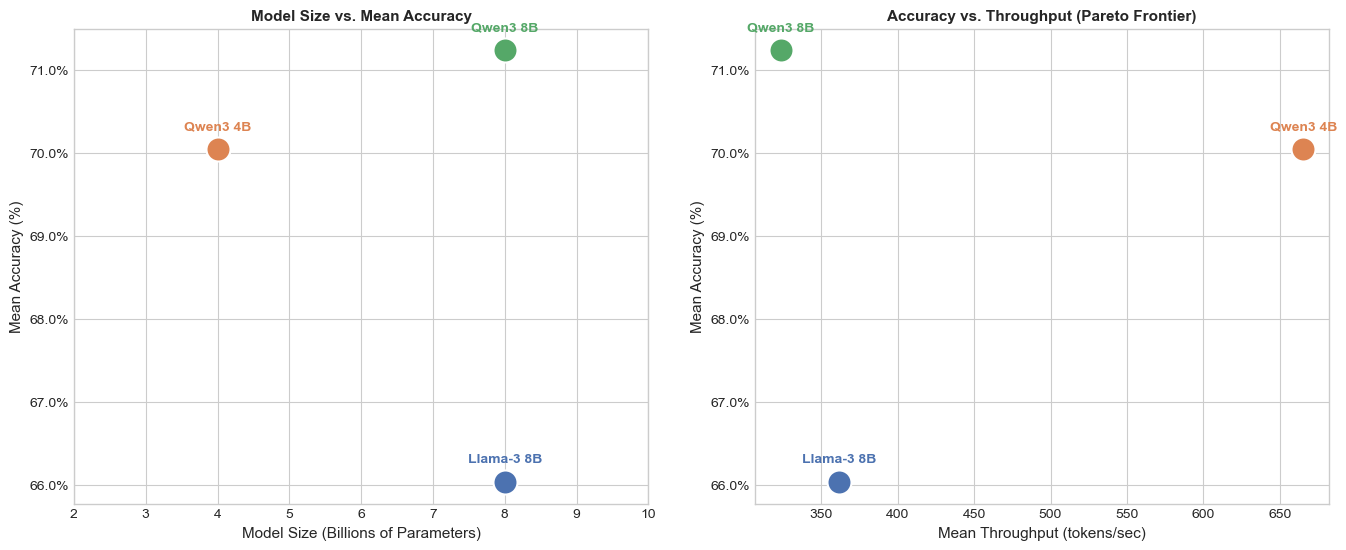

Saved: pareto_analysis.png


In [40]:
mean_acc = df.groupby('model')['accuracy'].mean()
mean_tps = df.dropna(subset=['gen_tokens_per_sec']).groupby('model')['gen_tokens_per_sec'].mean()

print('Mean accuracy per model (all 6 tasks):')
for m in MODELS_ORDERED:
    if m in mean_acc:
        print(f'  {m}: {mean_acc[m]*100:.2f}%')

print('\nMean throughput per model (tasks with timing):')
for m in MODELS_ORDERED:
    if m in mean_tps:
        print(f'  {m}: {mean_tps[m]:.1f} tok/s')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: size vs accuracy ────────────────────────────────────────────────
ax = axes[0]
for model in MODELS_ORDERED:
    if model in mean_acc:
        ax.scatter(MODEL_SIZES[model], mean_acc[model] * 100,
                   s=300, color=MODEL_COLORS[model], zorder=5, edgecolors='white', linewidths=1.5)
        ax.annotate(model, (MODEL_SIZES[model], mean_acc[model] * 100),
                    xytext=(0, 14), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold', color=MODEL_COLORS[model])

ax.set_xlabel('Model Size (Billions of Parameters)', fontsize=11)
ax.set_ylabel('Mean Accuracy (%)', fontsize=11)
ax.set_title('Model Size vs. Mean Accuracy', fontsize=11, fontweight='bold')
ax.set_xlim(2, 10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

# ── Right: throughput vs accuracy ─────────────────────────────────────────
ax2 = axes[1]
for model in MODELS_ORDERED:
    if model in mean_acc and model in mean_tps:
        ax2.scatter(mean_tps[model], mean_acc[model] * 100,
                    s=300, color=MODEL_COLORS[model], zorder=5, edgecolors='white', linewidths=1.5)
        ax2.annotate(model, (mean_tps[model], mean_acc[model] * 100),
                     xytext=(0, 14), textcoords='offset points',
                     ha='center', fontsize=10, fontweight='bold', color=MODEL_COLORS[model])

ax2.set_xlabel('Mean Throughput (tokens/sec)', fontsize=11)
ax2.set_ylabel('Mean Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy vs. Throughput (Pareto Frontier)', fontsize=11, fontweight='bold')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

plt.tight_layout(pad=2.5)
plt.savefig(os.path.join(OUT_DIR, 'pareto_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pareto_analysis.png')

## 10. Summary Dashboard

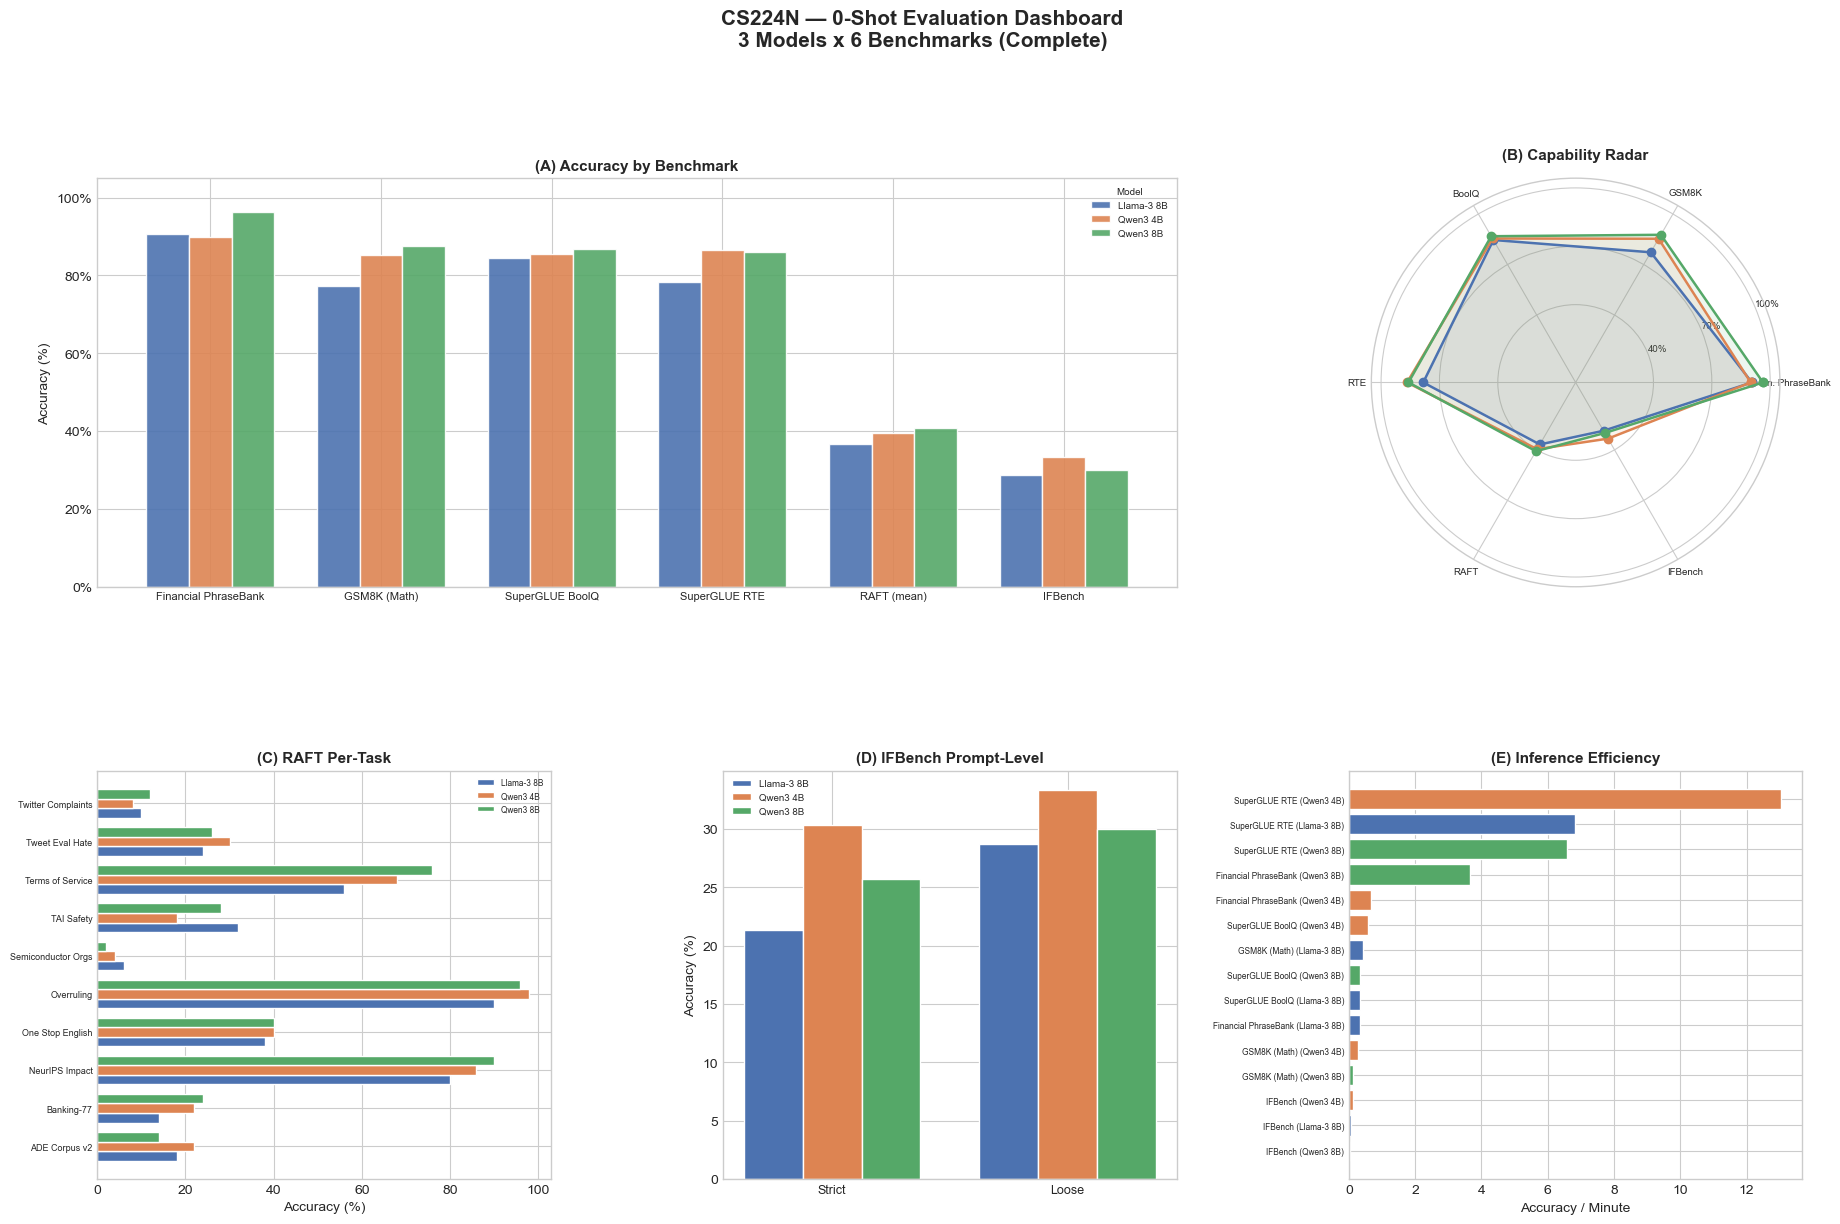

Saved: dashboard.png


In [41]:
fig = plt.figure(figsize=(22, 13))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_acc   = fig.add_subplot(gs[0, :2])
ax_radar = fig.add_subplot(gs[0, 2], polar=True)
ax_raft  = fig.add_subplot(gs[1, 0])
ax_if    = fig.add_subplot(gs[1, 1])
ax_eff   = fig.add_subplot(gs[1, 2])

# ── (A) Accuracy bars ─────────────────────────────────────────────────────
for i, model in enumerate(MODELS_ORDERED):
    vals = []
    for tl in ALL_TASKS_ORDERED:
        row = df[(df['task_label'] == tl) & (df['model'] == model)]
        vals.append(row['accuracy'].values[0] * 100 if len(row) else np.nan)
    ax_acc.bar(x + offsets[i], vals, width,
               label=model, color=MODEL_COLORS[model], edgecolor='white', alpha=0.9)
ax_acc.set_xticks(x); ax_acc.set_xticklabels(ALL_TASKS_ORDERED, fontsize=8)
ax_acc.set_ylabel('Accuracy (%)'); ax_acc.set_ylim(0, 105)
ax_acc.set_title('(A) Accuracy by Benchmark', fontweight='bold', fontsize=11)
ax_acc.legend(title='Model', fontsize=7, title_fontsize=7)
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# ── (B) Radar ─────────────────────────────────────────────────────────────
for model in MODELS_ORDERED:
    vals = []
    for tl in radar_tasks:
        row = df[(df['task_label'] == tl) & (df['model'] == model)]
        vals.append(row['accuracy'].values[0] if len(row) else 0)
    vals_c = vals + vals[:1]
    ax_radar.plot(angles, vals_c, 'o-', linewidth=1.8, label=model, color=MODEL_COLORS[model])
    ax_radar.fill(angles, vals_c, alpha=0.10, color=MODEL_COLORS[model])
ax_radar.set_xticks(angles[:-1]); ax_radar.set_xticklabels(radar_labels, fontsize=7)
ax_radar.set_ylim(0, 1.05); ax_radar.set_yticks([0.4, 0.7, 1.0])
ax_radar.set_yticklabels(['40%', '70%', '100%'], fontsize=7)
ax_radar.set_title('(B) Capability Radar', fontweight='bold', fontsize=11, pad=14)

# ── (C) RAFT grouped bars ─────────────────────────────────────────────────
if len(RAFT_TASK_NAMES) > 0:
    x_rr = np.arange(len(RAFT_TASK_NAMES))
    for i, model in enumerate(MODELS_ORDERED):
        vals = (raft_pivot[model].values * 100)
        ax_raft.barh(x_rr + (i - 1) * 0.25, vals, 0.25,
                     label=model, color=MODEL_COLORS[model], edgecolor='white')
    ax_raft.set_yticks(x_rr); ax_raft.set_yticklabels(RAFT_TASK_NAMES, fontsize=6.5)
ax_raft.set_xlabel('Accuracy (%)'); ax_raft.set_title('(C) RAFT Per-Task', fontweight='bold', fontsize=11)
ax_raft.legend(fontsize=6)

# ── (D) IFBench strict vs loose ───────────────────────────────────────────
for i, model in enumerate(MODELS_ORDERED):
    vals = [ifbench_df.loc[ifbench_df['Model'] == model, m].values[0] * 100
            for m in ['Strict Prompt', 'Loose Prompt']]
    ax_if.bar(np.arange(2) + (i - 1) * 0.25, vals, 0.25,
              label=model, color=MODEL_COLORS[model], edgecolor='white')
ax_if.set_xticks([0, 1]); ax_if.set_xticklabels(['Strict', 'Loose'], fontsize=9)
ax_if.set_ylabel('Accuracy (%)'); ax_if.set_title('(D) IFBench Prompt-Level', fontweight='bold', fontsize=11)
ax_if.legend(fontsize=7)

# ── (E) Efficiency ────────────────────────────────────────────────────────
eff_top = df_eff.sort_values('acc_per_min', ascending=True).tail(15)
clrs = [MODEL_COLORS[m] for m in eff_top['model']]
ylabels = eff_top['task_label'] + ' (' + eff_top['model'] + ')'
ax_eff.barh(ylabels, eff_top['acc_per_min'], color=clrs, edgecolor='white')
ax_eff.set_xlabel('Accuracy / Minute'); ax_eff.set_title('(E) Inference Efficiency', fontweight='bold', fontsize=11)
ax_eff.tick_params(axis='y', labelsize=6)

fig.suptitle('CS224N — 0-Shot Evaluation Dashboard\n3 Models x 6 Benchmarks (Complete)', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(os.path.join(OUT_DIR, 'dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dashboard.png')

## 11. Key Findings

In [42]:
print('=' * 70)
print('  CS224N 0-Shot Evaluation — Key Findings (Auto-Generated)')
print('=' * 70)

print('\n  FULL COVERAGE: 3 models x 6 benchmarks = 18 experiments')
print(f'  Missing cells: {df.shape[0]} / 18 loaded = '
      f'{"COMPLETE" if df.shape[0] >= 18 else "INCOMPLETE"}')

print('\n  ACCURACY HIGHLIGHTS')
for model in MODELS_ORDERED:
    sub = df[df['model'] == model]
    m_acc = sub['accuracy'].mean()
    best = sub.loc[sub['accuracy'].idxmax()]
    worst = sub.loc[sub['accuracy'].idxmin()]
    print(f'  {model:15s}  mean={m_acc*100:.1f}%'
          f'  best={best["accuracy"]*100:.1f}% ({best["task_label"]})'
          f'  worst={worst["accuracy"]*100:.1f}% ({worst["task_label"]})')

print('\n  THROUGHPUT HIGHLIGHTS')
df_t = df.dropna(subset=['gen_tokens_per_sec'])
fastest = df_t.loc[df_t['gen_tokens_per_sec'].idxmax()]
slowest = df_t.loc[df_t['gen_tokens_per_sec'].idxmin()]
print(f'  Fastest: {fastest["model"]} on {fastest["task_label"]}'
      f' -> {fastest["gen_tokens_per_sec"]:.0f} tok/s')
print(f'  Slowest: {slowest["model"]} on {slowest["task_label"]}'
      f' -> {slowest["gen_tokens_per_sec"]:.0f} tok/s')

mean_tps_by_model = df_t.groupby('model')['gen_tokens_per_sec'].mean()
for m in MODELS_ORDERED:
    if m in mean_tps_by_model:
        print(f'  {m:15s}  mean throughput = {mean_tps_by_model[m]:.0f} tok/s')

print('\n  RAFT ANALYSIS (10 subtasks, 0-shot)')
for model in MODELS_ORDERED:
    if model in raft_per_task:
        accs = [pt['accuracy'] for pt in raft_per_task[model]]
        best_task = max(raft_per_task[model], key=lambda x: x['accuracy'])
        worst_task = min(raft_per_task[model], key=lambda x: x['accuracy'])
        print(f'  {model:15s}  mean={np.mean(accs)*100:.1f}%  '
              f'std={np.std(accs)*100:.1f}%  '
              f'best={RAFT_NICE_NAMES.get(best_task["task"], best_task["task"])} ({best_task["accuracy"]*100:.0f}%)  '
              f'worst={RAFT_NICE_NAMES.get(worst_task["task"], worst_task["task"])} ({worst_task["accuracy"]*100:.0f}%)')

print('\n  IFBENCH ANALYSIS (instruction following, 300 prompts, 58 constraint types)')
for model in MODELS_ORDERED:
    d = ifbench_details.get(model, {})
    if d:
        print(f'  {model:15s}  strict={d["strict_prompt"]*100:.1f}%  '
              f'loose={d["loose_prompt"]*100:.1f}%  '
              f'throughput={d["tokens_per_sec"]:.0f} tok/s')

# Find the IFBench winner
if ifbench_details:
    best_if = max(ifbench_details.items(), key=lambda x: x[1].get('loose_prompt', 0))
    print(f'  Winner: {best_if[0]} (loose prompt {best_if[1]["loose_prompt"]*100:.1f}%)')

print('\n  CROSS-BENCHMARK INSIGHTS')
for model in MODELS_ORDERED:
    sub = df[df['model'] == model]
    accs = sub['accuracy'].values
    print(f'  {model:15s}  range=[{min(accs)*100:.1f}%, {max(accs)*100:.1f}%]  '
          f'spread={np.ptp(accs)*100:.1f}pp  '
          f'std={np.std(accs)*100:.1f}%')

print('\n  MODEL RANKINGS')
model_means = {m: df[df['model'] == m]['accuracy'].mean() for m in MODELS_ORDERED}
ranked = sorted(model_means.items(), key=lambda x: -x[1])
for rank, (m, v) in enumerate(ranked, 1):
    print(f'  #{rank} {m:15s}  {v*100:.2f}% mean accuracy')

print('\n  EFFICIENCY RANKING (mean accuracy / mean gen time)')
for m in MODELS_ORDERED:
    sub_e = df_eff[df_eff['model'] == m]
    if len(sub_e):
        eff = sub_e['accuracy'].mean() / sub_e['total_gen_time_min'].mean()
        print(f'  {m:15s}  {eff:.3f} acc/min')

print('\n' + '=' * 70)

  CS224N 0-Shot Evaluation — Key Findings (Auto-Generated)

  FULL COVERAGE: 3 models x 6 benchmarks = 18 experiments
  Missing cells: 18 / 18 loaded = COMPLETE

  ACCURACY HIGHLIGHTS
  Llama-3 8B       mean=66.0%  best=90.6% (Financial PhraseBank)  worst=28.7% (IFBench)
  Qwen3 4B         mean=70.1%  best=90.0% (Financial PhraseBank)  worst=33.3% (IFBench)
  Qwen3 8B         mean=71.2%  best=96.3% (Financial PhraseBank)  worst=30.0% (IFBench)

  THROUGHPUT HIGHLIGHTS
  Fastest: Qwen3 4B on GSM8K (Math) -> 1806 tok/s
  Slowest: Llama-3 8B on Financial PhraseBank -> 12 tok/s
  Llama-3 8B       mean throughput = 362 tok/s
  Qwen3 4B         mean throughput = 665 tok/s
  Qwen3 8B         mean throughput = 324 tok/s

  RAFT ANALYSIS (10 subtasks, 0-shot)
  Llama-3 8B       mean=36.8%  std=27.9%  best=Overruling (90%)  worst=Semiconductor Orgs (6%)
  Qwen3 4B         mean=39.6%  std=31.3%  best=Overruling (98%)  worst=Semiconductor Orgs (4%)
  Qwen3 8B         mean=40.8%  std=32.3%  best=Ov